# Customer journey: where does activation break?

Business question: which sequential journey step is the clearest product opportunity, and what is the denominator for each decision?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
with (ARTIFACTS / "results.json").open() as handle:
    results = json.load(handle)

def table(name, n=8):
    frame = pd.read_csv(ARTIFACTS / "tables" / name)
    display(frame.head(n))
    return frame

def figure(name):
    png = ARTIFACTS / "figures" / f"{name}.png"
    svg = ARTIFACTS / "figures" / f"{name}.svg"
    assert png.exists() and svg.exists(), f"missing paired figure outputs for {name}"
    assert "<svg" in svg.read_text(encoding="utf-8")[:1000]
    display(Image(filename=str(png), width=640))
    return png, svg


,stage,customers,conversion_from_signup,dropoff_from_previous,conversion_from_previous,metric_scope
0,signup,100000,1.00000,0.0,1.000000,sequential_funnel
1,onboarding_completed,74458,0.74458,25542.0,0.744580,sequential_funnel
2,account_funded,58078,0.58078,16380.0,0.780010,sequential_funnel
3,first_transaction_7d,42254,0.42254,15824.0,0.727539,sequential_funnel
4,repeat_usage,40996,0.40996,1258.0,0.970228,sequential_funnel
5,sustained_engagement_d30,20909,0.20909,20087.0,0.510025,sequential_funnel
6,d30_retention_overall,23604,0.23604,NaN,NaN,overall_retention


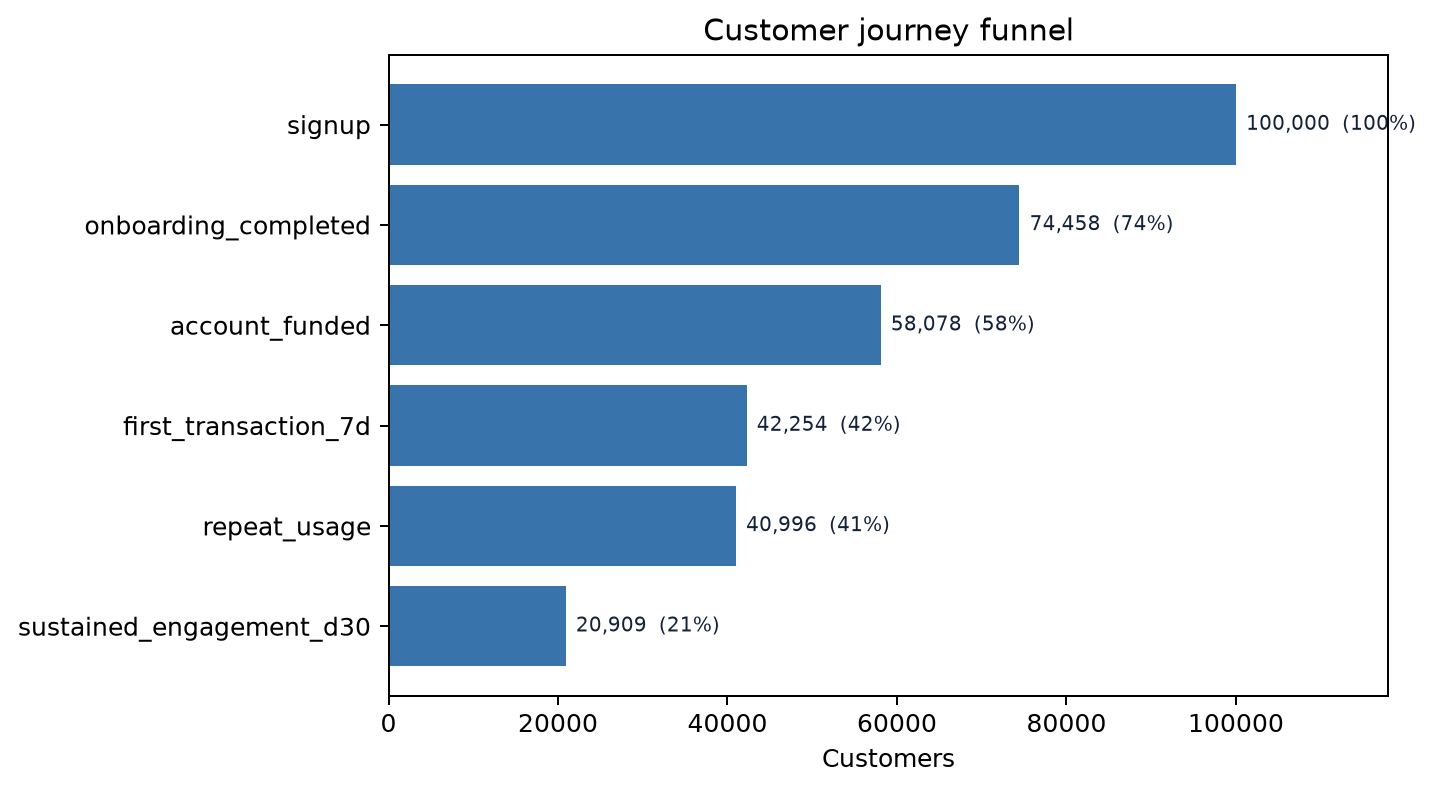

{'activation_rate': 0.42254, 'd30_retention': 0.23604, 'sequential_sustained_engagement_d30': 0.20909, 'activation_contract': 'Funded and at least one settled meaningful transaction in signup calendar days 0-7 inclusive.', 'retention_windows': {'d7': 'D7-13', 'd30': 'D30-36', 'd60': 'D60-66', 'd90': 'D90-96'}, 'mature_retention': {'d7': 0.29743245832693926, 'd30': 0.23600196563676398, 'd60': 0.20507190446969079, 'd90': 0.16267294516120848}}


In [2]:
journey = table('journey.csv')
figure('journey_funnel')
print(results['journey'])

In [3]:
early_stages = ['onboarding_completed', 'account_funded', 'first_transaction_7d']
early = journey.loc[journey['stage'].isin(early_stages)].copy()
weakest = early.loc[early['conversion_from_previous'].astype(float).idxmin()]
print(f"Evidence: the weakest early previous-stage conversion is {weakest['stage']!r} at {float(weakest['conversion_from_previous']):.1%}; the table preserves its denominator and scope.")
print('Decision: prioritise the weakest early conversion, then validate the product intervention with a controlled experiment.')

Evidence: the weakest early previous-stage conversion is 'first_transaction_7d' at 72.8%; the table preserves its denominator and scope.
Decision: prioritise the weakest early conversion, then validate the product intervention with a controlled experiment.


**Uncertainty and scope.** Uncertainty: this is synthetic, descriptive funnel evidence; it does not identify why customers drop or prove that an intervention will work.

**Decision framing.** Treat the generated artifacts as an auditable working read: inspect the source table, check assumptions, and validate the proposed action with an appropriate follow-up measurement.